# ADA final exam (Fall 2024)

This exam consists of 2 tasks. The two tasks are independent of each other. You can solve them in any order.

## Task 1: Natural Language Processing (44 pts)
This part of the exam will analyze a real-world negotiation dataset:

Two participants take the role of campsite neighbors and negotiate for Food, Water, and Firewood packages, based on their individual preferences and requirements. This design keeps the task tractable, while still facilitating linguistically rich and personal conversations.

At the end of each negotiation, both negotiators receive an outcome score (`outcome`) reflecting their success in achieving their goals. The dataset is divided into two data frames:

1. `df_negotiations`, with columns:
    - `negotiation_id`: the negotiation identifier
    - `agent`: the agent active in that turn, either `mt_agent_1` or `mt_agent_2` (first and second to interact)
    - `message`: the message sent to the other agent
    - `turn`: the negotiation turn
2. `df_meta`, meta information for each negotiation with the outcome and agent background:
    - `gender`: (male, female, other)
    - `age`: integer
    - `outcome`: integer

We are interested in finding out: what makes a good (/bad) negotiator?

### Part 1: Coding Questions (29 pt)

In [1]:
import pandas as pd

df_negotiations = pd.read_csv('data/negotiations.csv')
df_negotiations.head()

,agent,message,negotiation_id,turn
0,mturk_agent_1,Hello! 🙂 Let's work together on a deal for the...,0,0
1,mturk_agent_2,Hey! I'd like some more firewood to keep my do...,0,0
2,mturk_agent_1,I need firewood as well. We have a large group...,0,1
3,mturk_agent_2,I see. 😮 What are you least interested in?,0,1
4,mturk_agent_1,We can make do without extra water. Can we tra...,0,2


In [2]:
df_meta = pd.read_csv('data/negotiations_meta.csv')
df_meta.head()
# each negotiation id has the information about the 2 agents who spoke. 

,agent,age,gender,negotiation_id,outcome
0,mturk_agent_1,31,female,797,21
1,mturk_agent_2,26,male,797,15
2,mturk_agent_1,65,male,909,18
3,mturk_agent_2,34,female,909,23
4,mturk_agent_1,26,male,135,26


In [3]:
df_fil = df_meta[(df_meta['gender'] == 'male')& (df_meta['age'] == 26)]
df_fil.head()

,agent,age,gender,negotiation_id,outcome
1,mturk_agent_2,26,male,797,15
4,mturk_agent_1,26,male,135,26
12,mturk_agent_1,26,male,61,18
173,mturk_agent_2,26,male,939,5
196,mturk_agent_1,26,male,133,21


In [4]:
df_negotiations['negotiation_id'].unique()

array([  0,   1,  10, ..., 997, 998, 999], shape=(1028,))

In [5]:
# df = df_negotiations.groupby('negotiation_id')
df_fil = df_negotiations[(df_negotiations['negotiation_id'] == 0) ]
df_fil.head(33)

,agent,message,negotiation_id,turn
0,mturk_agent_1,Hello! 🙂 Let's work together on a deal for the...,0,0
1,mturk_agent_2,Hey! I'd like some more firewood to keep my do...,0,0
2,mturk_agent_1,I need firewood as well. We have a large group...,0,1
3,mturk_agent_2,I see. 😮 What are you least interested in?,0,1
4,mturk_agent_1,We can make do without extra water. Can we tra...,0,2
5,mturk_agent_2,We could do without the water as well. I'm wil...,0,2
6,mturk_agent_1,"We need some firewood too, though! ☹️ Let's tr...",0,3
7,mturk_agent_2,"I meant I would give you my firewood, what wou...",0,3
8,mturk_agent_1,"Oh sorry for the confusion. 😮 In that case, th...",0,4
9,mturk_agent_2,I can do that for 3 food and 3 water?,0,4


**1.1 (2 pt)**
/Discussion:/ We are interested in analyzing negotiation outcomes by analyzing language usage. In order to use TF-IDF to accomplish this, we will treat all turns from one negotiator in a single negotiation as a "document". Why would this definition of "document" be preferred over the following two alternatives? Give at least one argument per alternative.

- A) Each individual turn is a document
- B) The entire negotiation dialogue of both negotiators is a document

[your answer]

A cosiders sentence and its answer. A will lose the the info about the singolar indidivuduale. I mean, how cna we analyzize his negotiation skills if we consider just one setnece per time? With the propose alatenrtaive will have the negotionor history. 

B is also not preferred because having the all dialaogue consideraerd seperaly will loose the ifnormation accross different dialgoge. cna be  a acase that 1 negotiation went well, we want the all vision. 



**1.2 (3 pt)**

[A, 1 pt] Use the negotiation dataset to create a new dataframe called `df_document` with the following columns:
- `negotiation_id`
- `agent`
- `document`

Here, document is defined as described in question 1.1. That is: concatonate messages into a single string and split by the special character `"\n"`.

In [6]:
# assuming that for any single negotiation_id, the two agents are different people. they never did another negotiation. 

df_document = df_negotiations.groupby(['negotiation_id', 'agent'])['message']\
                             .apply(lambda message: '\n'.join(message))\
                             .reset_index()\
                             .rename(columns={'message':'document'})

df_document.head()

,negotiation_id,agent,document
0,0,mturk_agent_1,Hello! 🙂 Let's work together on a deal for the...
1,0,mturk_agent_2,Hey! I'd like some more firewood to keep my do...
2,1,mturk_agent_1,I am good. I am pretty excited for the trip th...
3,1,mturk_agent_2,Hello. How are you?\nVery excited. It will be ...
4,2,mturk_agent_1,Hi! How are you?! You excited for your camping...


In [7]:
print(df_document.loc[0, 'document'])

Hello! 🙂 Let's work together on a deal for these packages, shall we? What are you most interested in?
I need firewood as well. We have a large group consisting of mostly senior citizens, including my grandma, so we'd like the firewood to keep everyone warm.
We can make do without extra water. Can we trade two waters for an extra firewood package and an extra food package?
We need some firewood too, though! ☹️ Let's try to make a deal that benefits us both! 🙂 Could I have 1 firewood, 3 food, and 3 waters?
Oh sorry for the confusion. 😮 In that case, thank you for the generosity! 🙂 How about if I have 3 firewood, 1 food, and 1 water?
I think we're close. Let's shake hands on this: 3 firewood, 1 food for me, and then 2 food and 3 water for you. I'll make sure your food packages have extra doggy treats! 🙂 Is that a deal?
Accept-Deal


[B, 2pt] Next, merge this new dataframe with the `df_meta` dataframe. Print the the size and first five rows of the final dataframe

In [8]:
df_document = pd.merge(df_document,df_meta, on= ['negotiation_id', 'agent'])
print('Shape:', df_document.shape)

Shape: (2056, 6)


In [9]:
df_document.head(5)

,negotiation_id,agent,document,age,gender,outcome
0,0,mturk_agent_1,Hello! 🙂 Let's work together on a deal for the...,43,male,19
1,0,mturk_agent_2,Hey! I'd like some more firewood to keep my do...,22,female,18
2,1,mturk_agent_1,I am good. I am pretty excited for the trip th...,24,female,19
3,1,mturk_agent_2,Hello. How are you?\nVery excited. It will be ...,43,female,17
4,2,mturk_agent_1,Hi! How are you?! You excited for your camping...,30,female,14


**1.3 (7 pt)**
We would like to analyze the difference between "best" and "worst" performers based on `outcome`, top and bottom 10% respectively.

[A, 2 pt] Find the top and bottom 10% thresholds for the `outcome` columns and print them.

In [10]:
df_document.sort_values(by='outcome', ascending=False)

,negotiation_id,agent,document,age,gender,outcome
409,205,mturk_agent_2,"Okay, I can spare some water. Can you spare so...",44,male,32
1883,943,mturk_agent_2,"Greetings\nI plan to, sure. That will depends...",38,male,31
1640,822,mturk_agent_1,"Hi, what is your expectation about the deal?\n...",54,female,31
1620,812,mturk_agent_1,"I am well, how are you\nGreat. I am going camp...",24,male,29
1038,521,mturk_agent_1,"Howdy! Looking for firewood, water and food--r...",30,male,29
...,...,...,...,...,...,...
1267,635,mturk_agent_2,Can't wait to go on this trip. Taking the who...,57,male,5
88,44,mturk_agent_1,Kindly understand our need as we are strugglin...,30,male,5
89,44,mturk_agent_2,At the same from my side. We need foods becaus...,54,female,5
2031,1017,mturk_agent_2,I really need 3 packages of food because I wil...,29,male,5


In [11]:
import numpy as np
t_top = np.quantile(df_document['outcome'],q=0.90)
print(t_top)
#top = df_document[df_document['outcome'] > t_top ].sort_values(by='outcome', ascending=False)
#top.head()

23.0


In [12]:
t_bottom = np.quantile(df_document['outcome'],q=0.10)
print(t_bottom)
#bottom = df_document[df_document['outcome'] < t_bottom ].sort_values(by='outcome', ascending=True)
#bottom.head()

15.5


[B, 1pt] Create a TF-IDF matrix using the `TfidfVectorizer` form `sklearn`, setting `max_features=100` and `stop_words="english"`. Print the resulting TF-IDF matrix shape.

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=100,stop_words='english')
tf_idf_matrix = vectorizer.fit_transform(df_document['document'])

tf_idf_matrix.shape
# tf idf: docs*terms 

(2056, 100)

[C, 4pt] Use your thresholds and the TF-IDF matrix to print the top 10 terms for each type of negotiatior (i.e., the best and worst performing negotiators from question 1.3.A).

In [14]:
top = df_document[df_document['outcome'] > t_top ].sort_values(by='outcome', ascending=False).index

# top10_scores = tf_idf_matrix[top10].sum(axis=0) # per col
# we want the top 10 term across all top10 negotiators, we sum all the score for each negotiotor (each row) for each term (each col)
#  >>>>> sum might be bias by the size fo the group. we use the mean instead 

top_scores = tf_idf_matrix[top].mean(axis=0).A1 # .A1 = “array, 1D”
top_scores_idx = top_scores.argsort()[::-1][:10] # argsort() gives the position in the rank >> asc order  
                                                 # [::-1] reverses the array
                                                                  
terms = vectorizer.get_feature_names_out()
top_terms = {terms[i] for i in top_scores_idx}
print('Best terms:',top_terms)

Best terms: {'okay', 'water', 'need', 'extra', 'packages', 'want', 'firewood', 'submit', 'food', 'deal'}


In [15]:
bottom = df_document[df_document['outcome'] > t_bottom ].sort_values(by='outcome', ascending=True).index
bottom_scores = tf_idf_matrix[bottom].mean(axis=0).A1
bottom_scores_idx = bottom_scores.argsort()[::-1][:10]
                                                                  
bottom_terms = {terms[i] for i in bottom_scores_idx}
print('Bottom terms:',bottom_terms)

Bottom terms: {'camping', 'accept', 'water', 'need', 'like', 'extra', 'submit', 'food', 'firewood', 'deal'}


**1.4 (8 pt)**
You never get a second chance at a first impression! Let's investigate if the same goes for negotiations...

[A, 1pt] Create a new df_document that only takes into account the first three (3) turns of each negotiator in a negotiation. Again, merge on the df_meta dataframe and print the resulting size.

In [16]:
df_document_3t = df_negotiations['turn'].isin([1,2,3])
df_document_3t = df_negotiations[df_negotiations['turn'].isin([1,2,3])].groupby(['negotiation_id', 'agent'])['message']\
                             .apply(lambda message: '\n'.join(message))\
                             .reset_index()\
                             .rename(columns={'message':'document'})

df_document_3t = pd.merge(df_document_3t,df_meta, on= ['negotiation_id', 'agent'])
print('Shape:', df_document_3t.shape)
df_document_3t.head()

Shape: (2056, 6)


,negotiation_id,agent,document,age,gender,outcome
0,0,mturk_agent_1,I need firewood as well. We have a large group...,43,male,19
1,0,mturk_agent_2,I see. 😮 What are you least interested in?\nWe...,22,female,18
2,1,mturk_agent_1,"Yes, Hopefully the weather holds up. So I was ...",24,female,19
3,1,mturk_agent_2,Very excited. It will be fun.\nI would also li...,43,female,17
4,2,mturk_agent_1,I really am! I have been watching the weather ...,30,female,14


[B, 1pt] Calculate the median negotiation outcome. Then, add a column called success to the df_document dataframe that is 1 if the outcome column is more than the median and 0 otherwise. Print the median outcome.

In [17]:
median_outcome = df_document_3t['outcome'].median()
print('Median outcome', median_outcome)
df_document_3t['success'] =  (df_document_3t['outcome'] > median_outcome).astype(int)
df_document_3t

Median outcome 19.0


,negotiation_id,agent,document,age,gender,outcome,success
0,0,mturk_agent_1,I need firewood as well. We have a large group...,43,male,19,0
1,0,mturk_agent_2,I see. 😮 What are you least interested in?\nWe...,22,female,18,0
2,1,mturk_agent_1,"Yes, Hopefully the weather holds up. So I was ...",24,female,19,0
3,1,mturk_agent_2,Very excited. It will be fun.\nI would also li...,43,female,17,0
4,2,mturk_agent_1,I really am! I have been watching the weather ...,30,female,14,0
...,...,...,...,...,...,...,...
2051,1027,mturk_agent_2,"Awesome, I'm going to have a larger group with...",37,male,19,0
2052,1028,mturk_agent_1,Between us we have our hands full.🙂 So I am ho...,63,female,22,1
2053,1028,mturk_agent_2,I can work with that but is there any way I ca...,29,male,18,0
2054,1029,mturk_agent_1,I am a bit used to camping and that is why i p...,35,male,18,0


[C, 2pt] Create a TF-IDF matrix called `X` based on `df_document` using the following settings:

`max_features=100, stop_words="english, ngram_range=(1, 2)`

Additionally, create a variable `y` that corresponds to the success column. Finally, use `sklearn.model_selection.train_test_split` to split your data into a train and test set using parameters `test_size=0.2` and `random_state=99`.

Print the shape of the TF-IDF and the shape of your train and test sets.

In [18]:
from sklearn.model_selection import train_test_split

vectorizer = TfidfVectorizer(max_features=100,stop_words='english',ngram_range=(1,2))
X = vectorizer.fit_transform(df_document_3t['document'])
print('TF IDF shape:',X.shape)

y = df_document_3t['success']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,random_state=99)
print('TF IDF train shape:',X_train.shape)
print('TF IDF train shape:',X_test.shape)
print('y train shape:',y_train.shape)
print('y test shape:',y_test.shape)

TF IDF shape: (2056, 100)
TF IDF train shape: (1644, 100)
TF IDF train shape: (412, 100)
y train shape: (1644,)
y test shape: (412,)


[D, 2pt] Use your prepared data to train a logistic regression model (`sklearn.linear_model.LogisticRegression`). Then, with the trained model predict on the test set and print a classification report (`sklearn.metrics.classification_report`).

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

lr = LogisticRegression(random_state=99)
res = lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.64      0.91      0.75       264
           1       0.32      0.08      0.13       148

    accuracy                           0.61       412
   macro avg       0.48      0.49      0.44       412
weighted avg       0.52      0.61      0.53       412



[E, 2pt] Use the weights of your trained model to show which terms mostly strongly correlate with high and low outcomes. Print the best five terms for each.

In [20]:
# instead of tf idf, we use the weights 
w = lr.coef_[0]

# a strong correlation: 
# large positive w =  high outcome
# large negative w =  low outcome 

top_posw_idx = w.argsort()[::-1][:5]
top_posw_term = [terms[i] for i in top_posw_idx]
print('Top terms with high outcome according to weights:',  top_posw_term)


bottom_posw_idx = w.argsort()[:5]
bottom_posw_term = [terms[i] for i in bottom_posw_idx]
print('Top terms with low outcome according to weights: ',bottom_posw_term)


Top terms with high outcome according to weights: ['reject', 'taking', 'feel', 'oh', 'want']
Top terms with low outcome according to weights:  ['rest', 'll', 'hi', 'let', 'going']


**1.5 (9 pt)**
You are concerned about potential “confounding” factors for your results in the previous question. Specifically, you would like to investigate the effect of “gender” on the outcomes.

[A, 3pt] Visualize the outcomes stratified by gender using a bar plot with standard deviation around the mean. Make sure you use clear x- and y-axis labels, a title, and a legend.

Text(0, 0.5, 'mean outcome')

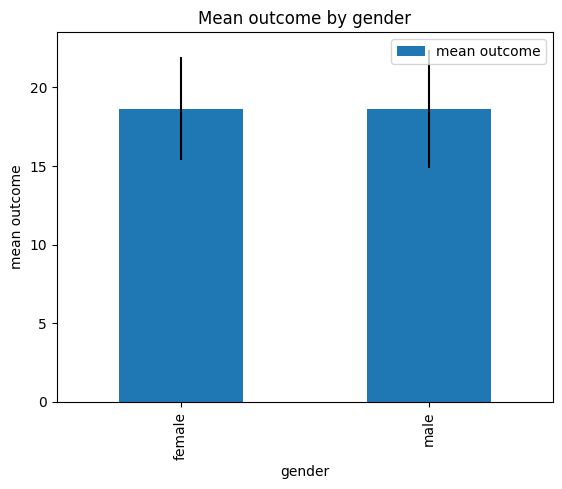

In [21]:
import matplotlib as plt

mean_outcome_gender = df_meta.groupby('gender')['outcome'].mean()
std_outcome_gender = df_meta.groupby('gender')['outcome'].std()
mean_outcome_gender.name = "mean outcome"

fig = mean_outcome_gender.plot.bar(x=df_meta['gender'],y=mean_outcome_gender,yerr=std_outcome_gender)
fig.set_title("Mean outcome by gender")
fig.legend()
fig.set_ylabel("mean outcome")

[B, 2pt] Perform a T-Test with a confidence interval of 0.95 to check if the outcomes based on gender are statistically significantly different. Print the resulting t-statistic, the p-value, and your interpretation of the result.

In [22]:
from scipy.stats import ttest_ind

tstat, pvalue = ttest_ind(df_meta.loc[df_meta['gender'] == 'male']['outcome'], df_meta.loc[df_meta['gender'] == 'female']['outcome'])
print(f"t-statistic: {tstat:.4f}, p-value: {pvalue:.4f}")
print("Significant difference" if pvalue < 0.05 else "No significant difference")

t-statistic: -0.1518, p-value: 0.8793
No significant difference


[C, 2pt] Finally, we would like to test if the gender distribution between high and low negotiation performers is significantly different. Please perform a chi-square test on the gender distribution of those negotiators scoring above the median outcome. Use a confidence interval of 0.95 and print the resulting chi-square statistic, p-value, and your interpretation of the result.

In [23]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(
    df_document_3t['gender'],
    df_document_3t['success']
)

chi2, p_value, _, _ = chi2_contingency(contingency)

# Interpret results
alpha = 0.05
print(f"chi-square-statistic: {chi2:.4f}, p-value: {pvalue:.4f}")
if p_value <= alpha:
    print("Reject the null hypothesis.")
    print("There is a significant difference in the gender distribution between high and low negotiation performance")
else:
    print("Fail to reject the null hypothesis.")
    print("There is not enough evidence to conclude a significant difference in the gender distribution between high and low negotiation performance")


chi-square-statistic: 0.0226, p-value: 0.8793
Fail to reject the null hypothesis.
There is not enough evidence to conclude a significant difference in the gender distribution between high and low negotiation performance


[D, 2pt] /Discuss:/ In addition to the gender attribute, could you think of other measurable factors in this dataset that could be tested as confounders? List at least two more and explain why.

age can be a coufounder cause older people might be consider wiser and have more power over people. 
order. who start firts might have more power.


### Part 2: Insight Questions (15 pt)

**2.1 (3pt)**
In the context of analyzing negotiation turns, why would TF-IDF be more suitable than simple word frequency counts when trying to identify distinctive communication patterns between successful and unsuccessful negotiations?

[your answer]

**2.2 (2pt)**
How would you modify the standard TF-IDF implementation to account for the temporal nature of negotiation turns? Consider that early turns might be more important for setting the tone of the negotiation than later turns.

[your answer]

**2.3 (3 pt)**
In our negotiation dataset, successful negotiators might simply write longer messages. How could this create a misleading interpretation of our TF-IDF results, and what would be a simple way to test for this potential bias?

[your answer]

**2.4 (3pt)**
In our negotiation dataset, consider these two opening messages from different agents:

Agent A: "I propose we split the resources fairly" Agent B: "I suggest we divide the assets equitably"

These messages are semantically very similar but use different vocabulary. Explain:

- a) How TF-IDF would process these messages differently
- b) How word embeddings (like Word2Vec) would handle them
- c) Why this distinction matters for negotiation analysis

[your answer]

**2.5 (4pt)**
Staying in the context of negotiations, explain why N-gram models such as bigrams might be more informative than unigrams for predicting negotiation outcomes. Provide two examples of bigrams that would be particularly meaningful in negotiation contexts but would lose their significance if split into unigrams.

[your answer]

## Task 2: Analysis of Co-Author Network (50 pts + 4 pts bonus)


In this part, you will analyze a reserach publication dataset derived from 
[social influence analysis in large-scale networks](https://keg.cs.tsinghua.edu.cn/jietang/publications/KDD09-Tang-et-al-Social-Influence-Analysis.pdf) (the paper itself is irrelevant to this exam, don't waste time reading it).

The citation data is extracted from DBLP, ACM, MAG (Microsoft Academic Graph), and other sources. Each paper is associated with abstract, authors, year, venue, and title.

Dataset: [citation dataset](https://cn.aminer.org/citation)

Paper: [social influence analysis in large-scale networks](https://keg.cs.tsinghua.edu.cn/jietang/publications/KDD09-Tang-et-al-Social-Influence-Analysis.pdf)


### Download data from the web

#### For Linux and MacOS:
```bash
curl https://lfs.aminer.cn/lab-datasets/citation/citation-network1.zip -o citation-network1.zip
unzip citation-network1.zip
ls -l outputacm.txt
```

#### For windows we recommend using WSL (Windows Subsystem for Linux) with above commands or directly downloading the file from the browser at 
https://lfs.aminer.cn/lab-datasets/citation/citation-network1.zip



In [24]:
import numpy as np
import pandas as pd
import scipy as sp
import networkx as nx
import matplotlib.pyplot as plt

from helper import load_data_as_df


# Define the file path
file_path = "data/outputacm.txt"

# Load the data into a DataFrame
df = load_data_as_df(file_path)

# check if the index column is the same as the index 

print(f"Dataset loaded with {len(df)} entries.")
print(f"colums: {df.columns}")

Dataset loaded with 629814 entries.
colums: Index(['title', 'authors', 'year', 'venue', 'references', 'abstract'], dtype='object')


In [25]:
df.head()

,title,authors,year,venue,references,abstract
0,Automated Deduction in Geometry: 5th Internati...,"[Hoon Hong, Dongming Wang]",2006.0,,[],None
1,A+ Certification Core Hardware (Text & Lab Man...,[Charles J. Brooks],2003.0,,[],None
2,Performance engineering in industry: current p...,"[Ahmed E. Hassan, Parminder Flora]",2007.0,Proceedings of the 6th international workshop ...,[],This panel session discusses performance engin...
3,"Dude, You Can Do It! How to Build a Sweeet PC","[Darrel Creacy, Carlito Vicencio]",2005.0,,[],Whether you're frustrated with current PC offe...
4,What Every Programmer Needs to Know about Secu...,"[Neil Daswani, Anita Kesavan]",2006.0,,[],None


**3.1 (6 pts)**: Analyze Papers Published Per Year

**Objective:**  
Analyze and visualize publication trends to understand how the research field has evolved over time.

#### Instructions:
1. Group the data by the year of publication and count the number of papers for each year (2 pts).
2. Plot a bar chart showing the number of papers published per year from **1990 to 2010**. (2 pts)
3. Focus on the pattern between **1996 and 2004**:
   - **Discuss:** Describe any notable trends or changes in the number of publications during this period. (2 pts)
   - **Bonus:** Hypothesize potential reasons for the observed pattern.  (2 pts)
     *Hint: Consider events or trends related to the dataset's focus on computer science.* 


Number of publications per <bound method Series.sort_index of year
1900        1
1941        1
1947        1
1949        1
1950        2
        ...  
2007    38312
2008    45378
2009    42842
2010      380
2018        1
Name: title, Length: 66, dtype: int64>


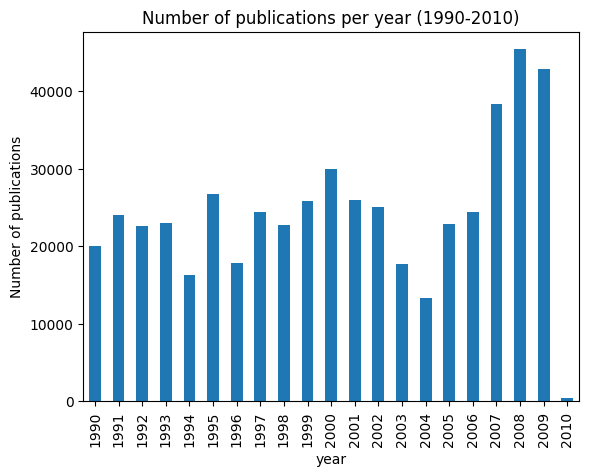

Text(0, 0.5, 'Number of publications')

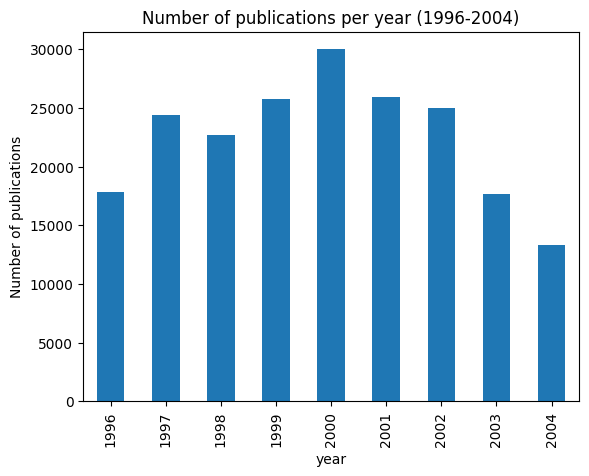

In [26]:
# (1)
df['year'] = df['year'].astype('Int64')
print('Number of publications per',df.groupby("year")["title"].count().sort_index)

# (2)
df_90_10 = df[(df['year'] >= 1990) & (df['year'] <= 2010)]
#print(df_90_10['year'].unique())
df_90_10_c = df_90_10.groupby("year")["title"].count()
df_90_10_c.plot.bar(y=df_90_10_c)
plt.title("Number of publications per year (1990-2010)")
plt.ylabel("Number of publications")
plt.show()

# (3)
df_96_04 = df[(df['year'] >= 1996) & (df['year'] <= 2004)]
df_96_04_c = df_96_04.groupby("year")["title"].count()
df_96_04_c.plot.bar(y=df_96_04_c)
plt.title("Number of publications per year (1996-2004)")
plt.ylabel("Number of publications")


We notice an increasing trend from 1996 to 2000, where the curve descends again. This might be due to the fact that the year 2000 represents a reference year. Being the entrance of a new century, a new era, authors want to propose their new hypothesis and technologies that will change the century, the so called "discovery of the century". 

**3.2 (4 pts)**: Authors Per Paper Analysis

With the rise of interdisciplinary research, multi-authored papers are becoming more common. This task will help us understand collaboration dynamics in the academic world.

#### Instructions:
- Get the number of authors for each paper and calculate the percentage of papers with four or more authors. (2 pts)
- Plot a histogram to show the frequency distribution of the number of authors per paper (2 pts)(choose `bins=range(0, 30)` and set y-axis to log scale).

Papers with 4 or more authors:82970, %: 13.17


Text(0, 0.5, 'Log number of papers')

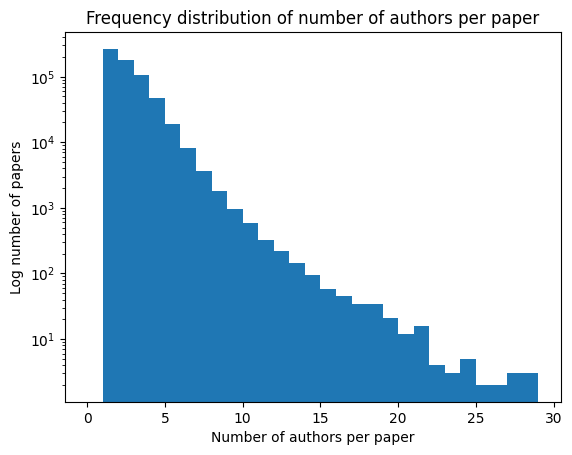

In [27]:
# (1)
df["NumAuthors"] = df['authors'].str.len()
count_pap_more4 = len(df[(df["NumAuthors"] >= 4)]['title'])
tot_pap = len(df)
print(f'Papers with 4 or more authors:{count_pap_more4}, %: {round(count_pap_more4/tot_pap *100,2)}')

# (2)
plt.hist(df["NumAuthors"], bins=range(0,30))
#plt.xlim(min(df["NumAuthors"]), max(df["NumAuthors"]))
plt.yscale("log")
plt.title("Frequency distribution of number of authors per paper")
plt.xlabel("Number of authors per paper")
plt.ylabel("Log number of papers")

**3.3 (4 pts)**: Temporal Collaboration Trends

Collaboration dynamics can change over time. This task will help us understand how collaboration trends have evolved in the academic world.

#### Instructions:
- Group the data by publication year, calculate the average number of authors per paper for each year, and create a line plot to visualize how it has changed from 1990 to 2010 (1 pt).
- **Discuss:** There has been a hypothesis that the number of authors per paper has increased over time. Based on the plot, do you agree with this hypothesis ? (1 pt)
- Compute the P-value of the hypothesis that the average number of authors per paper after 2000 is significantly higher than before 2000. (2 pts)

C:\Users\seves\AppData\Local\Temp\ipykernel_14464\962859234.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_90_10["NumAuthors"] = df_90_10['authors'].str.len()


Text(0, 0.5, 'Average number of authors per paper')

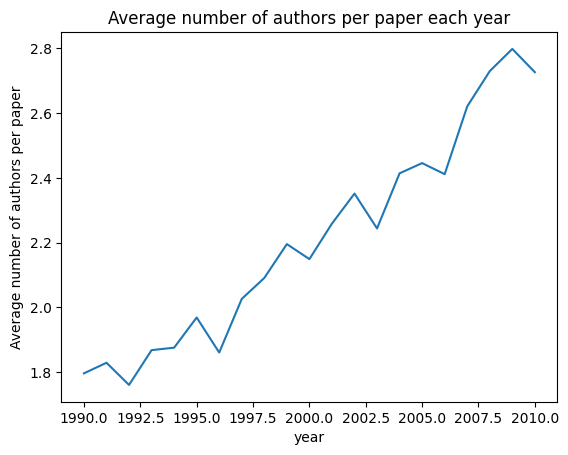

In [28]:
# (1)
df_90_10["NumAuthors"] = df_90_10['authors'].str.len()
df_90_10.groupby("year")["NumAuthors"].mean().plot.line()
plt.title("Average number of authors per paper each year")
plt.xlabel("year")
plt.ylabel("Average number of authors per paper")

In [29]:
# (2)
# The plots show an increase in average number of authors per paper through years. 

# (3)
from scipy.stats import ttest_ind

tstat, pvalue = ttest_ind(df[(df['year'] < 2000)]['NumAuthors'], df[(df['year'] > 2000)]['NumAuthors'])
print(f"t-statistic: {tstat:.4f}, p-value: {pvalue:.4f}")
print("Significant difference" if pvalue < 0.05 else "No significant difference")

t-statistic: -200.7348, p-value: 0.0000
Significant difference


**3.4 (6 pts)**: Build a Co-Author Network

Co-author networks help us visualize and quantify collaborations in academia. Such networks are critical for identifying influential researchers and their role in fostering connections within their communities. Construct a network where nodes represent authors and edges represent collaborations.

#### Instructions:
- Create a graph where: (5 pts)
  - Nodes: Each node represents a unique author, identified by their name in the authors field of the dataset.
  - Edges: There is an edge between two nodes if the corresponding authors have co-authored at least one paper. The weight of the edge represents the number of papers the two authors have co-authored together.
- After constructing the network, print the following information: (1 pt)
  - The total number of nodes (authors) in the network.
  - The total number of edges (collaborations) in the network.

Example:

For a paper authored by ["Alice", "Bob", "Charlie"], the graph should include:
- Nodes: Alice, Bob, Charlie.
- Edges: Alice-Bob, Alice-Charlie, Bob-Charlie, each with a weight of 1 (assuming no other collaborations between these pairs).


In [30]:
def create_coauthors_graph(df):
    G = nx.Graph() #undirect graph
    for author_list in df["authors"]: # per paper
        for i, author1 in enumerate(author_list):
            for author2 in author_list[i+1:]: # [i+1:] avoid duplicates (both Alice-Bob,Bob-Alice) and self loop (Alice-Alice)
                if G.has_edge(author1,author2):
                    G[author1][author2]["weight"] += 1
                else:
                    G.add_edge(author1,author2,weight=1)
    return G 

G = create_coauthors_graph(df)
print(G)
# nx.draw_spring(G, with_labels=True,  alpha = 0.8)

Graph with 505027 nodes and 1137185 edges


**3.5 (4 pts)**: Analyze the Co-Author Network

Connected components in a co-author network can reveal isolated research communities or dominant research hubs. Analyzing the largest component helps us understand the core of academic collaboration

#### Instructions:
- The degree of a node is the number of edges connected to it. In the context of the co-author network, this represents the number of distinct co-authors an author has collaborated with. Compute the average degree of the network (1 pt).
- Connectivity of the Network:
  - A network is fully connected if there is a path between every pair of nodes. Determine if the co-author network is fully connected (1 pt). (Hint: A single answer is not enough here. You need to use a method to verify the connectivity of the network.)
  - Can you tell how many authors are part of the largest connected component? How much does this account for the total number of authors in the network? (2 pt)
<!-- - Compute the average clustering coefficient of the network. -->

In [31]:
# (1)
average_degree = np.mean([d for n, d in G.degree()])
print('Average degree per node:',average_degree)

# (2a)
print("Is the graph fully connected?",nx.is_connected(G))

# (2b)
components = sorted(nx.connected_components(G), key=len, reverse=True)
largest_c = max(components, key=len)
# tot_authors = df['NumAuthors'].sum() does not count for unique names
tot_authors = len(G.nodes())
print(f'Authors in the largest connected component: {len(largest_c)}, in %: {round(len(largest_c)/tot_authors * 100,2)}')

Average degree per node: 4.503462191130375
Is the graph fully connected? False
Authors in the largest connected component: 342738, in %: 67.87


**3.6 (4 pts)**: Top Authors by Collaborations

#### Instructions:
- Get the degree for all nodes in the network and print the top 10 authors by degree (1 pt) (Note: some entries (e.g., "II," "III," "Jr.") may not represent real authors due to data quality issues. Please keep them in the list and don't do any cleaning.)
- A high degree  indicates that an author has collaborated with many other authors. However, it does not consider if the collaborations happen multiple times between the same authors. A weighted degree would be a better measure to consider the number of collaborations between authors. Get the top 10 authors by weighted degree. P.S. The weighted degree is the sum of the weights of the edges connected to the node. (1 pt)
- Which two authors have the highest number of collaborations? How many papers have they co-authored together? (2 pt)

In [32]:
# (1)
top10_auth_degree = sorted([(n,d) for n, d in G.degree()],key= lambda x: x[1])[::-1][:10] 
# lambda x: x[1] return the d >> we want to order by degree, x[0] orders by node

# print(top10_auth_degree) >>> [(' Jr.', 6343), (' III', 1340),..
print("Top 10 authors by degree:",[n for n,d in top10_auth_degree]) # ordered list

# (2)
top10_auth_weighted_degree = sorted([(n,wd) for n,wd in G.degree(weight='weight')],key= lambda x: x[1])[::-1][:10] 
print("Top 10 authors by weighted degree:",[n for n,wd in top10_auth_weighted_degree])

# (3)
# if we mean authors with higheest number of collaborations 
top2_auth_edges = sorted([(n,e) for n,e in G.edges()],key= lambda x: x[1])[::-1][:2] 
print("Top 2 authors by edges (number of collaborations):",[n for n,e in top2_auth_edges])

# if we a pairs of authors that collaborate the most
edge_weights = nx.get_edge_attributes(G, "weight")
top2_auth_edges = sorted(edge_weights.items(),key= lambda x: x[1])[::-1][:1] 
((author1, author2), num_papers) = top2_auth_edges[0]
print(f"Top pair of authors that collaborate the most:{author1, author2}, Papers published together: {num_papers}")


Top 10 authors by degree: [' Jr.', ' III', ' II', 'Wei Wang', 'Ming Li', 'Wei Li', 'Lei Zhang', 'Elisa Bertino', 'Hector Garcia-Molina', 'Yan Zhang']
Top 10 authors by weighted degree: [' Jr.', ' III', ' II', 'Philip S. Yu', 'Wei Wang', 'Elisa Bertino', 'Ming Li', 'Ron Kikinis', 'Thomas J. Cashman', 'Hector Garcia-Molina']
Top 2 authors by edges (number of collaborations): ['Simon K. Warfield', 'Emil Jovanov']
Top pair of authors that collaborate the most:('Gary B. Shelly', 'Thomas J. Cashman'), Papers published together: 156


**3.7 (4 pts)**: Analyze the reference/citation information 

Understanding the citation patterns of papers helps reveal their academic impact and how knowledge propagates through the research community. In this task, you will analyze the reference and citation relationships within the dataset.

First, let's create a citation network where:
- Nodes: Each node represents a unique paper, identified by its id in the dataset.
- Edges: There is an edge from paper A to paper B if paper A cites paper B. 


#### Instructions:
- **Discuss:** Is it reasonable that the citation network contains cycles?  What would a cycle( not self loop) in the citation network represent? (2 pt)
- Which paper has the highest number of citations? How many papers cite this paper? (1 pt)
- Which paper has the highest number of references? How many papers does this paper cite? (1 pt)


In [33]:
def create_citation_graph(df):
    G = nx.DiGraph() # directed graph
    for paper_id, ref_list in zip(df.index, df['references']):
        for ref in ref_list: # multiple ref in each paper
            G.add_edge(paper_id,ref)
    return G 
# not a weighthed direct graph 'cuz the same paper does not referred to the same paper twice. 

Gc = create_citation_graph(df)
nx.set_node_attributes(Gc, df['title'].to_dict(), 'title') # set attribute from the df
print(Gc)

DiGraph with 217335 nodes and 632751 edges


In [34]:
# (1)
# a cycle a citation network represents the fact the a group of papers cites between themself. 
# It is not possibile >> a paper publish before cannot cite a paper published after, but it is possible the contrary.

# (2) highest citations means highest in degree
top_pap_cited = sorted([(n,id) for n, id in Gc.in_degree()],key= lambda x: x[1])[::-1]
(top_paper_c, pap_that_cited) = top_pap_cited[0]
print(f"Most cited paper is N.{top_paper_c} '{Gc.nodes[top_paper_c]['title']}', Number of papers that cited it: {pap_that_cited}")
# print attribute info

# (3) histest number of reference  means highest out degree
top_pap_ref= sorted([(n,id) for n, id in Gc.out_degree()],key= lambda x: x[1])[::-1]
(top_paper_r, pap_that_ref) = top_pap_ref[0]
print(f"Paper with the most references is N.{top_paper_r} '{Gc.nodes[top_paper_r]['title']}', Number of references: {pap_that_ref}")


Most cited paper is N.453387 'Introduction to algorithms', Number of papers that cited it: 816
Paper with the most references is N.216749 'Query evaluation techniques for large databases', Number of references: 195


**3.8 (3 pts)**: Analyze the Citation Distribution 

The citation distribution of papers can provide insights into the impact of research publications. In this task, you will analyze the citation distribution in the dataset.

<!-- - Plot the number of papers having a certain level of citation x (x-axis) against x (y-axis) in a log-log scale. -->
- Create a frequency distribution where the x-axis represents the number of citations and the y-axis represents the number of papers that have that number of citations. Plot two scatters plot of the frequency distribution first in a normal scale and second in a log-log scale. (2 pts)
- **Discuss**: What does the plot suggest about the citation distribution in the dataset? (1 pt)

Text(0, 0.5, 'LogNumber of papers')

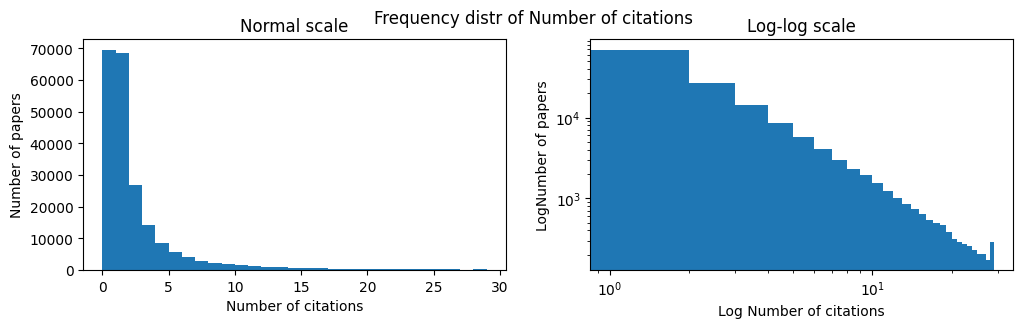

In [35]:
n = [(n,id) for n, id in Gc.in_degree()]
df_c = pd.DataFrame(n, columns=["paper_id", "citedIn"])

fig, ax = plt.subplots(1,2,figsize=(12,3))
fig.suptitle("Frequency distr of Number of citations")

ax[0].hist(df_c["citedIn"], bins=range(0,30))
ax[0].set_title("Normal scale")
ax[0].set_xlabel("Number of citations")
ax[0].set_ylabel("Number of papers")

ax[1].hist(df_c["citedIn"], bins=range(0,30))
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_title("Log-log scale")
ax[1].set_xlabel("Log Number of citations")
ax[1].set_ylabel("LogNumber of papers")

Text(0, 0.5, 'LogNumber of papers')

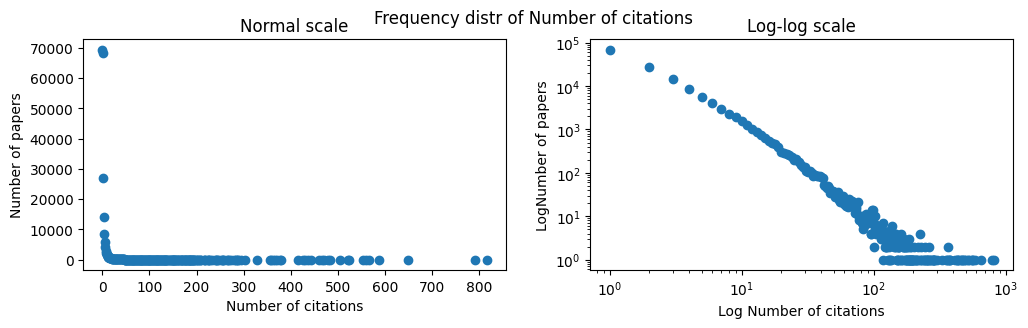

In [36]:
n = [(n,id) for n, id in Gc.in_degree()]
df_c = pd.DataFrame(n, columns=["paper_id", "citedIn"])
freq =  df_c['citedIn'].value_counts().sort_index()

fig, ax = plt.subplots(1,2,figsize=(12,3))
ax = ax.flatten()

fig.suptitle("Frequency distr of Number of citations")

ax[0].scatter(freq.index,freq.values)
ax[0].set_title("Normal scale")
ax[0].set_xlabel("Number of citations")
ax[0].set_ylabel("Number of papers")

ax[1].scatter(freq.index,freq.values)
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_title("Log-log scale")
ax[1].set_xlabel("Log Number of citations")
ax[1].set_ylabel("LogNumber of papers")

Suggest that the distribution as a power law. 

**3.9 (3 pts)**: Central Tendency of Citation Distribution

**Discuss:**: There are different ways to describe the central tendency of a citation distribution., such as mean. Determine the measure you think best represents the dataset and explain your reasoning. (Hint: Consider the distribution of the citation data above)


Being the distribution of data a power law, the mean is not a good way to describe the central tendency, it could be really already there are really large numbers.  Rather the median is more informative, cause it give the 50th quantile of the data and give actually a measure of centrality. 


Or geometric mean

**3.10 (2pts)**: Network Centrality Measures

PageRank is a measure of influence based on link structure. Applying it to citations allows us to rank papers by their academic importance

#### Instructions:
- You are tasked with curating the 'Top 10 Influential Papers' from this dataset. Use PageRank to justify your selection and display the top 10 papers titles by page rank. (2 pts)
- **bonus**: Identify patterns among the top-ranked papers. (2 pts)


In [37]:
# (1)
top10_influential = sorted(nx.pagerank(Gc).items(),key=lambda x: x[1])[::-1][:10] # you get a list of tuples

print("Top 10 influential papers (by pagerank):")
for paper_id, pr_score in top10_influential:
    title = Gc.nodes[paper_id]['title']
    print(f"{title}")

# (bonus)
# The books are from a CS topics

Top 10 influential papers (by pagerank):
The art of computer programming, volume 1 (3rd ed.): fundamental algorithms
The art of computer programming, volume 2 (3rd ed.): seminumerical algorithms
A relational model of data for large shared data banks
A method for obtaining digital signatures and public-key cryptosystems
Introduction to algorithms
Simulation Modeling and Analysis, 2nd edition
Compilers: principles, techniques, and tools
C4.5: programs for machine learning
Smalltalk-80: the language and its implementation
The nature of statistical learning theory


**3.11 (5 pts)**: Bridge Papers

Bridge papers are those that connect different research communities. They are essential for fostering interdisciplinary research and knowledge transfer. 

#### Instructions: 
- Build a small citation network that only includes papers published in 2005. (2 pts)
- Which measurement can help us identify bridge papers in a citation network?  (2 pt)
- Try to find top10 bridge papers in the dataset. By looking at their titles, can you identify the research communities they connect? (Pick 2 papers) (1 pt)



In [39]:
# (1)
Gc2005 = create_citation_graph(df[df['year'] == 2005])
print(Gc2005)

# (2)
# betweeness centrality

DiGraph with 26300 nodes and 30777 edges


In [ ]:
# (3)
top10_bridge_pap = sorted(nx.betweenness_centrality(Gc2005).items(),key=lambda x: x[1])[::-1][:10]

print("Top 10 Bridge papers (by betweenness centrality):")
for paper_id, pr_score in top10_bridge_pap:
    title = Gc.nodes[paper_id]['title']
    print(f"{title}")

**3.12 (5 pts)**: Author-Citation Network

In the previous tasks, we analyzed the co-author network and paper-citation network. In this task, we will analyze the author-citation network, where:
- Nodes: Each node represents a unique author, identified by their name in the authors field of the dataset.
- Edges: There is an edge from author A to author B if author A cites a paper authored by author B. 
- The weight of the edge represents the total number of citations from author A to author B.

#### Instructions:
Given that we have a Author-Paper Matrix $A$ where each row represents an paper and each column represents an author. The value in the matrix is 1 if the author has contributed to the paper, 0 otherwise. And we also have a Paper-Paper citation matrix $P$ (square matrix) where the value at coordinates (i, j) is 1 if paper j cites paper i, 0 otherwise.
- How can you get a Author-Author citation matrix from the above two matrices by matrix multiplication? (You don't need to implement this, just give the formula) (2 pts)
- Author A may have never cited author B, but author A might have cited a few papers which cited works by author B. This can be seen as a 2nd degree citation.  More formally, a 2nd degree citation matrix $C_2$ has at each cell (i, j) the number 2nd degree citations from author i to author j. How can you get a 2nd degree citation matrix from the Author-Paper Matrix $A$ and Paper-Paper citation matrix $P$? (You don't need to implement this, just give the formula) (2 pts)
- Can you generalize this to nth degree citation matrix? (1 pt)

- $A^T P A $
- $A^T P^2 A $
- $A^T P^n A $